# Snapshot eval violins — seed comparison across two sources

Compares **per-episode eval metrics** across differently *seeded* eval reruns of **two
different sources**, drawn side by side at each seed. This combines
`snapshot_eval_violins_seeds.ipynb` (seed fan-out on the x-axis) with
`snapshot_eval_violins.ipynb` (two coloured groups): at each seed the x-axis carries
**two violins next to each other** — one per source — so e.g. seed 42 shows the RBC
baseline's violin beside the SAC policy's violin for that same seed.

Each **source** is one snapshot evaluated under one eval kind (plus a rule-based
strategy for `eval-rbc`). The default `SOURCES` pairs a SAC policy (snapshot 1,
`eval-ray`) against a rule-based baseline (snapshot 2, `eval-rbc`), but any two sources
can be compared.

| `eval-kind` | Run directory pattern | Producer | Per-run CSV | Seed metadata |
|---|---|---|---|---|
| `eval-ray` | `runs/eval_<ts>[_seed{N}]/` | Ray RLlib eval (`run_eval_ray.py`) | `eval_results/*_eval/eval_*.csv` | sidecar JSON `"seed"` |
| `eval-sb` | `runs/eval_sb_<ts>[_seed{N}]/` | SB3 eval (`run_eval_sb.py`) | `eval_results/*_eval/eval_*.csv` | sidecar JSON `"seed"` |
| `eval-rbc` | `runs/eval_rbc_<ts>[_seed{N}]/` | Rule-based eval (`run_eval_rule_based.py`) | `eval_results/*_rule_based/<strategy>/episodes.csv` | `args.json` `"resolved_seed"` |

The actual seed a run used is read from that run's own metadata — never parsed from the
directory name — so the un-suffixed default run still gets its correct (`trial.seed`)
label. Produce the per-snapshot seed fan-outs with `submit_snapshot_eval_seeds.sh`.

**Main input:** set `SOURCES` in the next cell.

In [1]:
# --- Main input ---------------------------------------------------------------------
# The two (or more) sources to compare side by side at each seed. Each source is one
# snapshot evaluated under one eval kind; at every seed the x-axis draws one violin per
# source. Keys per entry:
#   path          snapshot dir (absolute, or relative to the repo root)
#   eval-kind     "eval-ray" | "eval-sb" | "eval-rbc" — which runs/eval_* fan-out to use
#   label         short name shown in the legend and used as the per-seed violin group
#   color         violin fill colour for this source
#   rbc-strategy  (eval-rbc only) which rule-based strategy to compare across seeds
SOURCES = [
    {
        "path": "snapshots/20260703_004926_sta_lin_battery_only_price_sac",
        "eval-kind": "eval-ray",
        "label": "SAC",
        "color": "#75aef4",  # RL blue, matching snapshot_eval_violins.ipynb
    },
    {
        "path": "snapshots/20260704_144904_sta_lin_battery_only_price_ppo",
        "eval-kind": "eval-ray",
        "label": "PPO",
        "color": "#f1bd2d",  # RL orange, matching snapshot_eval_violins.ipynb
    },
    {
        "path": "snapshots/20260705_234931_sta_lin_battery_only_price_rbc_base",
        "eval-kind": "eval-rbc",
        "rbc-strategy": "price_median_scaled_0.25",
        "label": "RBC \n(price_median_scaled_0.25)",
        "color": "#89f0cc",  # RBC green, matching snapshot_eval_violins.ipynb
    },
]
# Rule-based strategies available in the RBC snapshot above (pick one for "rbc-strategy"):
# ['deficit_discharge', 'do_nothing', 'price_median', 'price_median_autarky',
#  'price_median_scaled_0.25', 'price_median_scaled_0.5', 'price_median_scaled_0.75',
#  'pv_surplus_charge', 'self_coverage']

# Seeds to exclude from every figure and table below (applied after discovery, to both
# sources). Leave empty to keep all discovered seeds, e.g. EXCLUDE_SEEDS = [140, 141].
EXCLUDE_SEEDS: list[int] = [45, 46, 70, 140]

METRICS = ("total_reward", "cum_E_kWh", "cum_price_EUR")


In [2]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

EVAL_KINDS = ("eval-ray", "eval-sb", "eval-rbc")


# Walk upwards from the cwd until the directory containing snapshots/ is found, so the
# notebook runs both from plotting/ and from the repo root.
def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "snapshots").is_dir():
            return candidate
    raise FileNotFoundError("No 'snapshots/' directory found upwards of the cwd — run inside the repo.")


REPO_ROOT = _find_repo_root()


# Maps a runs/eval_* directory to its eval kind — mirrors the run-id scheme
# tools/snapshot/submit_snapshot.py builds from --kind.
def _run_dir_eval_kind(run_dir: Path) -> str:
    if run_dir.name.startswith("eval_rbc_"):
        return "eval-rbc"
    if run_dir.name.startswith("eval_sb_"):
        return "eval-sb"
    return "eval-ray"


# Ray/SB3 eval CSV's sidecar JSON (same stem) carries the actual trial.seed this run used.
def _sidecar_seed(csv_path: Path) -> int | None:
    sidecar = csv_path.with_suffix(".json")
    if not sidecar.is_file():
        return None
    try:
        return json.loads(sidecar.read_text()).get("seed")
    except (json.JSONDecodeError, OSError):
        return None


# Rule-based episodes.csv's sibling args.json (one level above the per-strategy dir) records resolved_seed.
def _rbc_resolved_seed(csv_path: Path) -> int | None:
    args_path = csv_path.parent.parent / "args.json"
    if not args_path.is_file():
        return None
    try:
        return json.loads(args_path.read_text()).get("resolved_seed")
    except (json.JSONDecodeError, OSError):
        return None


# Discovers one record per seed-run for a single source: its CSV path and the actual seed
# read from that run's own metadata (never parsed from the directory name).
def _discover_source_records(source: dict) -> list[dict]:
    eval_kind = source["eval-kind"]
    if eval_kind not in EVAL_KINDS:
        raise ValueError(f"'eval-kind' must be one of {EVAL_KINDS}, got {eval_kind!r}")

    snapshot_dir = Path(source["path"])
    snapshot_dir = snapshot_dir if snapshot_dir.is_absolute() else REPO_ROOT / snapshot_dir
    if not snapshot_dir.is_dir():
        raise FileNotFoundError(f"Snapshot directory not found: {snapshot_dir}")

    run_dirs = [
        run_dir for run_dir in sorted((snapshot_dir / "runs").glob("eval_*"))
        if _run_dir_eval_kind(run_dir) == eval_kind
    ]
    if not run_dirs:
        raise FileNotFoundError(f"No '{eval_kind}' run directories found under {snapshot_dir / 'runs'}")

    records = []
    for run_dir in run_dirs:
        if eval_kind == "eval-rbc":
            strategy = source.get("rbc-strategy")
            for csv_path in sorted(run_dir.glob("eval_results/*_rule_based/*/episodes.csv")):
                if strategy is not None and csv_path.parent.name != strategy:
                    continue
                records.append({
                    "source": source["label"], "snapshot_dir": snapshot_dir,
                    "run": run_dir.name, "seed": _rbc_resolved_seed(csv_path), "csv": csv_path,
                })
        else:
            for csv_path in sorted(run_dir.glob("eval_results/*_eval/eval_*.csv")):
                records.append({
                    "source": source["label"], "snapshot_dir": snapshot_dir,
                    "run": run_dir.name, "seed": _sidecar_seed(csv_path), "csv": csv_path,
                })
    if not records:
        raise FileNotFoundError(
            f"No eval CSVs discovered for source '{source['label']}' ({eval_kind}) under {snapshot_dir}"
        )
    return records


source_labels = [source["label"] for source in SOURCES]
if len(source_labels) != len(set(source_labels)):
    raise ValueError(f"Every source needs a unique 'label' (it names the per-seed violin group); got {source_labels}")
source_palette = {source["label"]: source["color"] for source in SOURCES}

eval_records: list[dict] = []
for source in SOURCES:
    eval_records.extend(_discover_source_records(source))

print(f"Repo root: {REPO_ROOT}")
for source in SOURCES:
    records = [record for record in eval_records if record["source"] == source["label"]]
    strategy = f", strategy={source.get('rbc-strategy')}" if source["eval-kind"] == "eval-rbc" else ""
    print(f"\nSource '{source['label']}' ({source['eval-kind']}{strategy}): {source['path']}")
    for record in sorted(records, key=lambda record: (record["seed"] is None, record["seed"])):
        print(f"  seed {str(record['seed']):>5}  <-  {record['run']}")


Repo root: /hkfs/home/haicore/iai/dj0397/AdvBuildingGym

Source 'SAC' (eval-ray): snapshots/20260703_004926_sta_lin_battery_only_price_sac
  seed    42  <-  eval_20260705_231614
  seed    43  <-  eval_20260706_104547_seed43
  seed    44  <-  eval_20260706_105216_seed44
  seed    45  <-  eval_20260706_105449_seed45
  seed    46  <-  eval_20260706_105502_seed46
  seed    70  <-  eval_20260706_105510_seed70
  seed    71  <-  eval_20260706_112012_seed71
  seed   140  <-  eval_20260706_111954_seed140
  seed   141  <-  eval_20260706_112005_seed141

Source 'PPO' (eval-ray): snapshots/20260704_144904_sta_lin_battery_only_price_ppo
  seed    42  <-  eval_20260705_231616
  seed    43  <-  eval_20260706_113732_seed43
  seed    44  <-  eval_20260706_113733_seed44
  seed    45  <-  eval_20260706_113734_seed45
  seed    46  <-  eval_20260706_113735_seed46
  seed    70  <-  eval_20260706_113737_seed70
  seed    71  <-  eval_20260706_113738_seed71
  seed   140  <-  eval_20260706_113739_seed140
  seed 

## Align the seeds

One record per (source, seed). Runs whose seed could not be resolved from metadata are
dropped. The x-axis is the sorted union of seeds seen across the sources (after dropping any in `EXCLUDE_SEEDS`); a warning is
printed if the sources do not cover exactly the same seeds — seaborn simply leaves a gap
where a source has no run for a seed.

In [3]:
_missing_seed = [record for record in eval_records if record["seed"] is None]
for record in _missing_seed:
    print(f"WARNING: could not resolve the seed for {record['csv']} — dropped")
eval_records = [record for record in eval_records if record["seed"] is not None]
if not eval_records:
    raise FileNotFoundError("No eval CSVs with a resolvable seed were discovered.")

# Drop any explicitly excluded seeds (EXCLUDE_SEEDS) from every figure and table below.
_excluded_set = set(EXCLUDE_SEEDS)
_dropped = sorted({record["seed"] for record in eval_records if record["seed"] in _excluded_set})
if _dropped:
    print(f"Excluding seed(s) {_dropped} (EXCLUDE_SEEDS).")
eval_records = [record for record in eval_records if record["seed"] not in _excluded_set]
if not eval_records:
    raise ValueError(f"EXCLUDE_SEEDS={EXCLUDE_SEEDS} removed every discovered run — nothing left to plot.")

# One violin per (source, seed): flag duplicate seeds within a source (their episodes
# would pool into a single violin for that seed).
for source in SOURCES:
    seeds = [record["seed"] for record in eval_records if record["source"] == source["label"]]
    duplicates = sorted({seed for seed in seeds if seeds.count(seed) > 1})
    if duplicates:
        print(f"WARNING: source '{source['label']}' has multiple runs for seed(s) {duplicates} — "
              "their episodes are pooled into one violin per seed.")

# x-axis: the sorted union of seeds; warn where a source is not seed-aligned with the union.
seed_order = sorted({record["seed"] for record in eval_records})
for source in SOURCES:
    source_seeds = {record["seed"] for record in eval_records if record["source"] == source["label"]}
    missing = [seed for seed in seed_order if seed not in source_seeds]
    if missing:
        print(f"WARNING: source '{source['label']}' has no run for seed(s) {missing} — "
              "those seeds show only the other source's violin.")


def _display_path(csv_path: Path) -> str:
    try:
        return str(csv_path.relative_to(REPO_ROOT))
    except ValueError:
        return str(csv_path)


pd.DataFrame(
    {"source": record["source"], "seed": record["seed"], "run": record["run"], "csv": _display_path(record["csv"])}
    for record in sorted(eval_records, key=lambda record: (record["seed"], source_labels.index(record["source"])))
)


Excluding seed(s) [45, 46, 70, 140] (EXCLUDE_SEEDS).


,source,seed,run,csv
0,SAC,42,eval_20260705_231614,snapshots/20260703_004926_sta_lin_battery_only...
1,PPO,42,eval_20260705_231616,snapshots/20260704_144904_sta_lin_battery_only...
2,RBC \n(price_median_scaled_0.25),42,eval_rbc_20260705_234932,snapshots/20260705_234931_sta_lin_battery_only...
3,SAC,43,eval_20260706_104547_seed43,snapshots/20260703_004926_sta_lin_battery_only...
4,PPO,43,eval_20260706_113732_seed43,snapshots/20260704_144904_sta_lin_battery_only...
5,RBC \n(price_median_scaled_0.25),43,eval_rbc_20260706_133838_seed43,snapshots/20260705_234931_sta_lin_battery_only...
6,SAC,44,eval_20260706_105216_seed44,snapshots/20260703_004926_sta_lin_battery_only...
7,PPO,44,eval_20260706_113733_seed44,snapshots/20260704_144904_sta_lin_battery_only...
8,RBC \n(price_median_scaled_0.25),44,eval_rbc_20260706_133839_seed44,snapshots/20260705_234931_sta_lin_battery_only...
9,SAC,71,eval_20260706_112012_seed71,snapshots/20260703_004926_sta_lin_battery_only...


## Load per-episode metrics

Every CSV is concatenated into one long-format frame, one row per episode, tagged with
its `source` and `seed`. A CSV missing a metric column is simply absent from that
metric's figure.

In [4]:
frames = []
for record in eval_records:
    csv_frame = pd.read_csv(record["csv"])
    present = [metric for metric in METRICS if metric in csv_frame.columns]
    missing = [metric for metric in METRICS if metric not in csv_frame.columns]
    if missing:
        print(f"note: source '{record['source']}' seed {record['seed']} lacks {missing} — skipped in those figures")
    frame = csv_frame[present].copy()
    frame["source"] = record["source"]
    frame["seed"] = record["seed"]
    frames.append(frame)

episodes = pd.concat(frames, ignore_index=True)
present_metrics = [metric for metric in METRICS if metric in episodes.columns]

episodes.groupby(["seed", "source"], sort=True).agg(
    episodes=("seed", "size"),
    **{f"mean_{metric}": (metric, "mean") for metric in present_metrics},
)


episodes  mean_total_reward  \
seed source                                                          
42   PPO                                     10          13.471870   
     RBC \n(price_median_scaled_0.25)        10           9.735845   
     SAC                                     10          14.235960   
43   PPO                                     10          13.555764   
     RBC \n(price_median_scaled_0.25)        10           9.918905   
     SAC                                     10          13.904051   
44   PPO                                     10          12.434005   
     RBC \n(price_median_scaled_0.25)        10           9.202446   
     SAC                                     10          13.045857   
71   PPO                                     10          14.371391   
     RBC \n(price_median_scaled_0.25)        10          10.852509   
     SAC                                     10          15.020272   
141  PPO                                     10          12.395909   
     RBC \n(price_median_scaled_0.25)        10           7.744611   
     SAC                                     10          12.884280   

                                       mean_cum_E_kWh  mean_cum_price_EUR  
seed source                                                                
42   PPO                                    46.765021           -3.618641  
     RBC \n(price_median_scaled_0.25)       42.604213           -2.698555  
     SAC                                    42.087546           -3.463104  
43   PPO                                    47.921760           -3.571893  
     RBC \n(price_median_scaled_0.25)       44.112668           -2.692047  
     SAC                                    43.331903           -3.286020  
44   PPO                                    47.893163           -3.683443  
     RBC \n(price_median_scaled_0.25)       43.865742           -3.006988  
     SAC                                    43.303306           -3.664672  
71   PPO                                    48.098967           -4.381068  
     RBC \n(price_median_scaled_0.25)       44.034734           -3.397704  
     SAC                                    43.578278           -4.092103  
141  PPO                                    46.061401           -3.713324  
     RBC \n(price_median_scaled_0.25)       41.522957           -2.418653  
     SAC                                    42.861213           -3.415747

## Violin plots

At each seed the sources are drawn as **dodged violins side by side** (coloured by the
`SOURCES` colours: blue = first source, green = second); individual episodes are overlaid
as dodged dots. Each violin carries two stat markers: **mean** (red dot) and **median**
(narrow dashed line). Each figure is saved into **every** source snapshot's `stat/`
directory as `violin_<metric>_seed_compare_<src1>_vs_<src2>.pdf`.

`violin_for_metric(metric, title_override=...)` replaces the default figure title.

In [5]:
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid", context="notebook")

METRIC_LABELS = {
    "total_reward": "Total reward per episode",
    "cum_E_kWh": "Cumulative energy consumption [kWh]",
    "cum_price_EUR": "Cumulative energy price [EUR]",
}

# Stat markers drawn on top of each violin (replaces seaborn's faint inner box)
MEAN_COLOR = "#e34948"  # red dot
MEDIAN_COLOR = "#1a1a19"  # narrow dashed line
MEDIAN_DASH = (0, (4, 2))

DODGE_WIDTH = 0.8  # seaborn violinplot default `width` — the per-seed slot the sources share
_seed_position = {seed: index for index, seed in enumerate(seed_order)}


# Centre offset of a source's dodged violin within a seed's slot, so the stat markers land
# on the exact violin seaborn draws for that (seed, source). Matches seaborn's even hue split.
def _dodge_offset(source_label: str) -> float:
    hue_index = source_labels.index(source_label)
    return DODGE_WIDTH * ((hue_index + 0.5) / len(source_labels) - 0.5)


# Overlays each dodged violin's mean (red dot) and median (narrow dashed line).
def _draw_stat_markers(ax, data: pd.DataFrame, metric: str) -> None:
    half_width = 0.9 * (DODGE_WIDTH / len(source_labels)) / 2
    stats = data.groupby(["seed", "source"])[metric].agg(["mean", "median"])
    for (seed, source), row in stats.iterrows():
        if seed not in _seed_position or source not in source_labels:
            continue
        x_position = _seed_position[seed] + _dodge_offset(source)
        ax.hlines(
            row["median"], x_position - half_width, x_position + half_width,
            color=MEDIAN_COLOR, linewidth=0.9, linestyle=MEDIAN_DASH, zorder=5,
        )
        ax.scatter(
            x_position, row["mean"],
            color=MEAN_COLOR, s=18, edgecolor="white", linewidth=0.5, zorder=6,
        )


_compare_tag = re.sub(r"\W+", "_", "_vs_".join(source_labels)).strip("_").lower()
_snapshot_dirs = sorted({record["snapshot_dir"] for record in eval_records}, key=str)


# Draws one violin per source at each seed for `metric` and exports the figure as a PDF
# into every source snapshot's stat/. `title_override` replaces the default figure title.
def violin_for_metric(metric: str, title_override: str | None = None) -> None:
    data = episodes.dropna(subset=[metric]) if metric in episodes.columns else episodes.iloc[0:0]
    if data.empty:
        print(f"no data for '{metric}' — figure skipped")
        return

    figure_width = max(8.0, 0.9 * len(seed_order) * len(source_labels))
    fig, ax = plt.subplots(figsize=(figure_width, 5.0))
    sns.violinplot(
        data=data,
        x="seed",
        y=metric,
        hue="source",
        order=seed_order,
        hue_order=source_labels,
        palette=source_palette,
        dodge=True,  # two violins side by side per seed
        density_norm="area",
        inner=None,  # the stat markers below replace seaborn's faint inner box
        linewidth=1.0,
        saturation=1.0,
        ax=ax,
    )
    sns.stripplot(
        data=data, x="seed", y=metric, hue="source",
        order=seed_order, hue_order=source_labels, dodge=True,
        palette={source: "0.1" for source in source_labels},
        size=3, alpha=0.6, jitter=0.08, legend=False, ax=ax,
    )
    _draw_stat_markers(ax, data, metric)

    ax.set_xlabel("Seed")
    ax.set_ylabel(METRIC_LABELS.get(metric, metric))
    ax.set_title(title_override if title_override else f"{metric} — {' vs '.join(source_labels)} by seed", pad=12)
    ax.grid(axis="x", visible=False)

    # Legend: the source colours seaborn built + the mean/median stat markers, outside the axes.
    source_handles, source_legend_labels = ax.get_legend_handles_labels()
    stat_handles = [
        Line2D([], [], color=MEAN_COLOR, marker="o", linestyle="none", markersize=5,
               markeredgewidth=0.5, label="mean"),
        Line2D([], [], color=MEDIAN_COLOR, linewidth=0.9, linestyle=MEDIAN_DASH, label="median"),
    ]
    ax.legend(
        handles=source_handles + stat_handles,
        labels=source_legend_labels + [handle.get_label() for handle in stat_handles],
        title="", frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0,
    )
    sns.despine(ax=ax)
    fig.tight_layout()

    for snapshot_dir in _snapshot_dirs:
        stat_dir = snapshot_dir / "stat"
        stat_dir.mkdir(parents=True, exist_ok=True)
        pdf_path = stat_dir / f"violin_{metric}_seed_compare_{_compare_tag}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")
        print(f"saved {pdf_path}")
    plt.show()


saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260703_004926_sta_lin_battery_only_price_sac/stat/violin_total_reward_seed_compare_sac_vs_ppo_vs_rbc_price_median_scaled_0_25.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_144904_sta_lin_battery_only_price_ppo/stat/violin_total_reward_seed_compare_sac_vs_ppo_vs_rbc_price_median_scaled_0_25.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260705_234931_sta_lin_battery_only_price_rbc_base/stat/violin_total_reward_seed_compare_sac_vs_ppo_vs_rbc_price_median_scaled_0_25.pdf


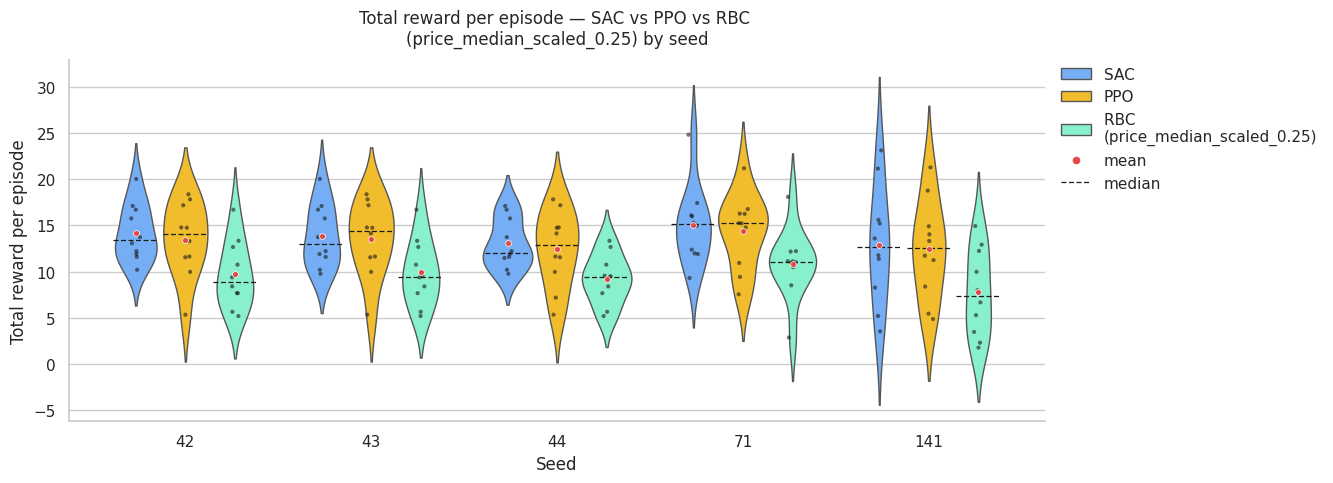

In [6]:
violin_for_metric("total_reward",
    title_override=f"Total reward per episode — {' vs '.join(source_labels)} by seed")


saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260703_004926_sta_lin_battery_only_price_sac/stat/violin_cum_E_kWh_seed_compare_sac_vs_ppo_vs_rbc_price_median_scaled_0_25.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_144904_sta_lin_battery_only_price_ppo/stat/violin_cum_E_kWh_seed_compare_sac_vs_ppo_vs_rbc_price_median_scaled_0_25.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260705_234931_sta_lin_battery_only_price_rbc_base/stat/violin_cum_E_kWh_seed_compare_sac_vs_ppo_vs_rbc_price_median_scaled_0_25.pdf


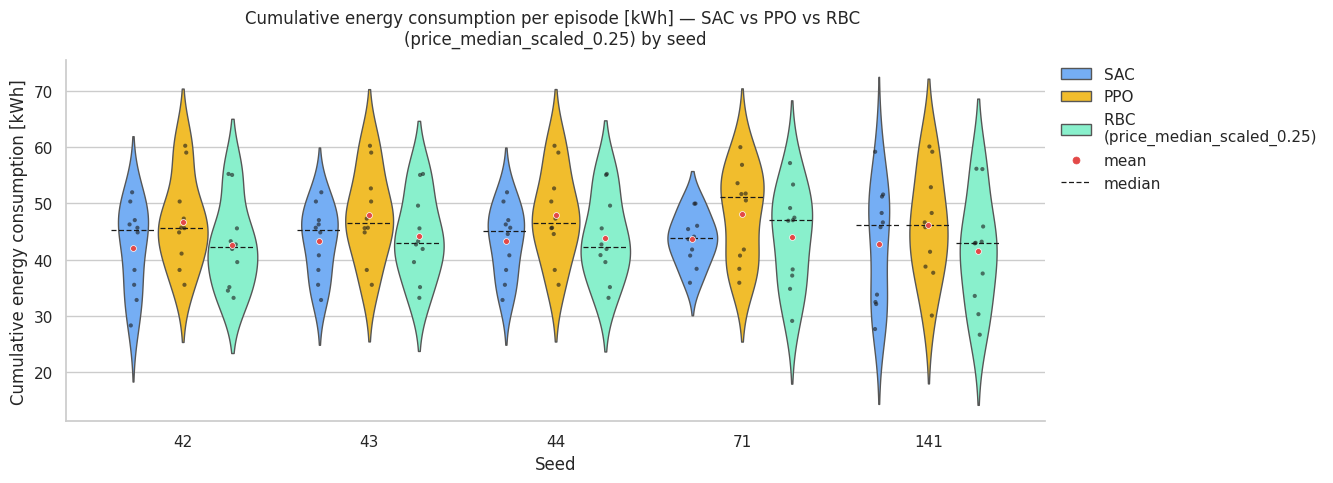

In [7]:
violin_for_metric("cum_E_kWh",
    title_override=f"Cumulative energy consumption per episode [kWh] — {' vs '.join(source_labels)} by seed")


saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260703_004926_sta_lin_battery_only_price_sac/stat/violin_cum_price_EUR_seed_compare_sac_vs_ppo_vs_rbc_price_median_scaled_0_25.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_144904_sta_lin_battery_only_price_ppo/stat/violin_cum_price_EUR_seed_compare_sac_vs_ppo_vs_rbc_price_median_scaled_0_25.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260705_234931_sta_lin_battery_only_price_rbc_base/stat/violin_cum_price_EUR_seed_compare_sac_vs_ppo_vs_rbc_price_median_scaled_0_25.pdf


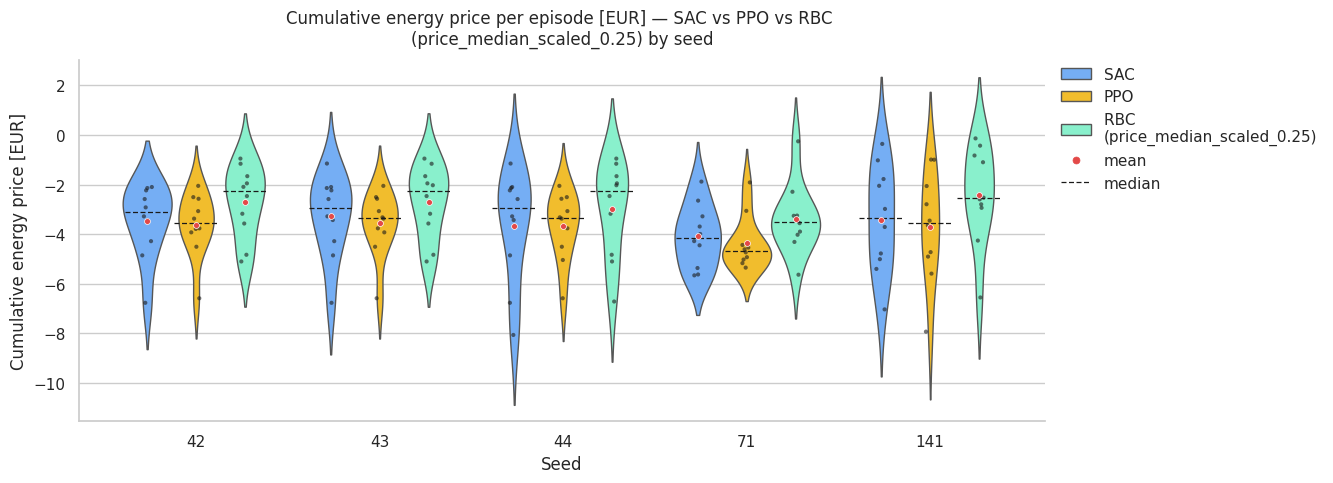

In [8]:
violin_for_metric("cum_price_EUR",
    title_override=f"Cumulative energy price per episode [EUR] — {' vs '.join(source_labels)} by seed")


## Variance across seeds, per source

For each source, the metric mean is first taken within each seed, then aggregated
(`mean` / `std` / `min` / `max`) across seeds — a small `std` means that source's
per-episode metrics generalise consistently across the differently seeded held-out data
draws. Comparing the sources' `std` shows which is the more seed-robust.

In [9]:
present_metrics = [metric for metric in METRICS if metric in episodes.columns]
seed_means = episodes.groupby(["source", "seed"])[present_metrics].mean()
seed_means.groupby("source").agg(["mean", "std", "min", "max"])


total_reward                                  \
                                         mean       std        min        max   
source                                                                          
PPO                                 13.245788  0.835982  12.395909  14.371391   
RBC \n(price_median_scaled_0.25)     9.490863  1.143448   7.744611  10.852509   
SAC                                 13.818084  0.879714  12.884280  15.020272   

                                  cum_E_kWh                                  \
                                       mean       std        min        max   
source                                                                        
PPO                               47.348062  0.892406  46.061401  48.098967   
RBC \n(price_median_scaled_0.25)  43.228063  1.133187  41.522957  44.112668   
SAC                               43.032449  0.588033  42.087546  43.578278   

                                 cum_price_EUR                                
                                          mean       std       min       max  
source                                                                        
PPO                                  -3.793674  0.332965 -4.381068 -3.571893  
RBC \n(price_median_scaled_0.25)     -2.842790  0.373601 -3.397704 -2.418653  
SAC                                  -3.584329  0.314799 -4.092103 -3.286020